## Analyzing and Predicting Spotify Audio Features for Focus-Friendly Music

This project explores whether certain Spotify audio features are associated with music that is better suited for focus or studying.

Using a dataset of Spotify tracks, I analyze characteristics such as acousticness, instrumentalness, energy, speechiness, and tempo to investigate how they relate to concentration-oriented listening.

First, I create a heuristic focus score to estimate how suitable a song may be for focus environments. I then extend the project with machine learning by training and comparing two Logistic Regression models: a baseline model using all heuristic-related features, and a revised model using a reduced feature set to create a more realistic and interpretable classification task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#display plots inside notebook
%matplotlib inline

In [3]:
#load Spotify tracks dataset into DataFrame
df = pd.read_csv("data/spotify_tracks.csv")

#preview first 5 rows of data
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
#remove extra index columns
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])

#preview cleaned dataset
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [6]:
#summary statistics for numeric columns
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Initial Exploration

Before building a focus score, we first explore the basic structure of the dataset and the distribution of one important feature: tempo.

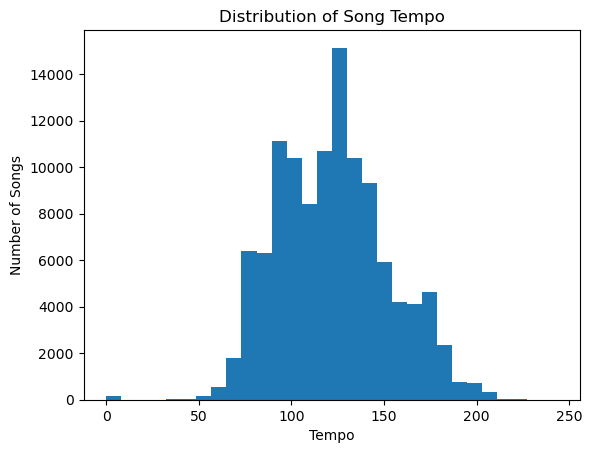

In [7]:
#histogram for tempo
plt.hist(df["tempo"], bins=30)
plt.title("Distribution of Song Tempo")
plt.xlabel("Tempo")
plt.ylabel("Number of Songs")
plt.show()

## Correlation Analysis

To understand how Spotify audio features relate to one another, we compute a correlation matrix using only numeric variables and visualize it as a heatmap.

In [8]:
#select only numerical columns
numeric_features = df.select_dtypes(include=["float64", "int64"])

#compute and display correlation matrix
correlation_matrix = numeric_features.corr()
correlation_matrix

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
danceability,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138
instrumentalness,-0.095139,0.124371,-0.185606,-0.181879,-0.006823,-0.433477,-0.049955,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330,-0.082580


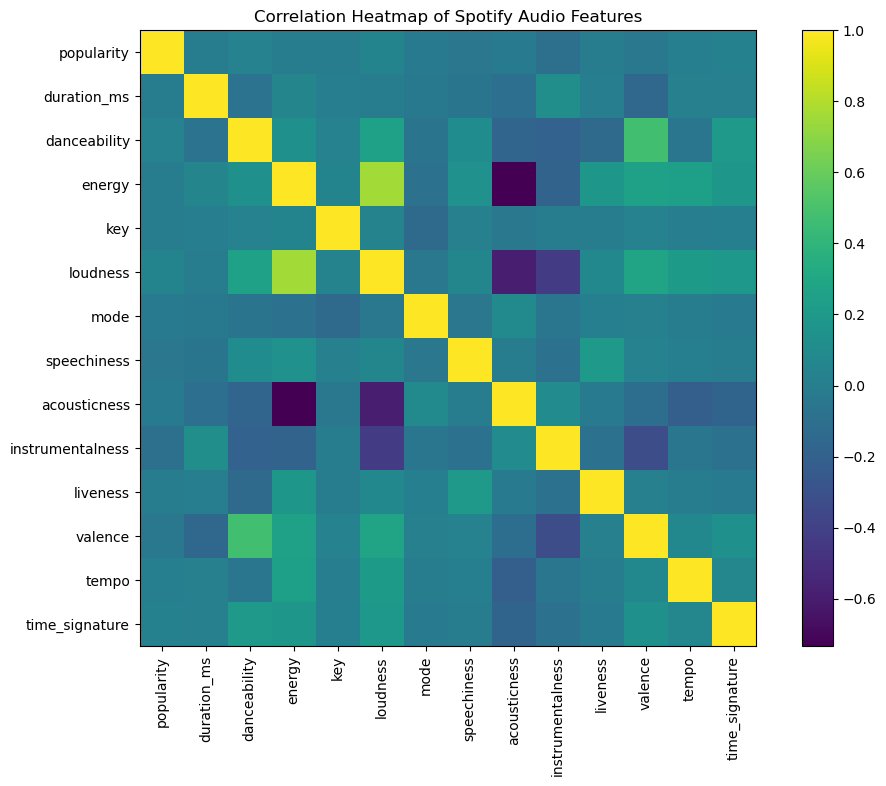

In [9]:
plt.figure(figsize=(12,8))

#display correlation matrix as a colored heatmap
plt.imshow(correlation_matrix)

plt.colorbar()

#axis labels and title
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

plt.title("Correlation Heatmap of Spotify Audio Features")

#save chart to images folder
plt.savefig("images/correlation_heatmap.png", bbox_inches="tight")

plt.show()

## Acousticness Check

Because acousticness is an important part of the focus score, we first check the tracks with the highest acousticness values to confirm that this feature is behaving realistically.

In [10]:
#sort songs by acousticness from highest to lowest
#higher acousticness = more acoustic/calmer music
acoustic_songs = df.sort_values(by="acousticness", ascending=False)

#display top 10 most acoustic songs
acoustic_songs[["track_name", "artists", "acousticness", "energy", "tempo"]].head(10)

,track_name,artists,acousticness,energy,tempo
76220,"Jeux d'enfants, Op. 22 WD 56: 3. La poupée",Georges Bizet;Katia Labèque;Marielle Labèque,0.996,0.00747,63.975
93322,Как цветок душистый,Yuri Morfessi,0.996,0.11800,85.342
16523,Gnossienne No. 1,Erik Satie;Alena Cherny,0.996,0.00579,71.827
79475,Zakochany,Aleksy Wysocki,0.996,0.09450,65.224
54854,Low Density,Obfusc,0.996,0.03610,94.889
16251,"Kinderszenen, Op. 15: 7. Träumerei",Robert Schumann;Alfred Brendel,0.996,0.01510,134.251
5412,You're in Love,Joe Hisaishi,0.996,0.03440,67.101
101932,Underwater Bubbles,Underwater Deep Sleep White Noise Nature Ocean...,0.996,0.96300,76.909
26962,In a World of My Own,Walt's Piano,0.996,0.03300,110.008
108617,La Muchacha del Arrabal,Carlos Gardel,0.996,0.34900,127.754


## Creating a Focus Score

To estimate how suitable a song may be for studying or focus environments, we define a simple rule-based focus score using several audio features.

Songs that are:
- more acoustic
- more instrumental
- lower in energy
- lower in speech

are hypothesized to be a better fit for focus-oriented listening.

This score is experimental and is meant for exploratory analysis rather than as a definitive recommendation model.

In [11]:
#create column called focus_score

#focus-friendly tracks tend to be acoustic, instrumental, low-energy, and low in speechiness

#focus_score = acousticness + instrumentalness - energy - speechiness

df["focus_score"] = (
    df["acousticness"]      
    + df["instrumentalness"] 
    - df["energy"]           
    - df["speechiness"]      
)

#display the first few rows of the features we used in the formula and the resulting focus_score
df[["track_name", "artists", "acousticness", "instrumentalness", "energy", "speechiness", "focus_score"]].head()

,track_name,artists,acousticness,instrumentalness,energy,speechiness,focus_score
0,Comedy,Gen Hoshino,0.0322,0.000001,0.4610,0.1430,-0.571799
1,Ghost - Acoustic,Ben Woodward,0.9240,0.000006,0.1660,0.0763,0.681706
2,To Begin Again,Ingrid Michaelson;ZAYN,0.2100,0.000000,0.3590,0.0557,-0.204700
3,Can't Help Falling In Love,Kina Grannis,0.9050,0.000071,0.0596,0.0363,0.809171
4,Hold On,Chord Overstreet,0.4690,0.000000,0.4430,0.0526,-0.026600


## Ranking Tracks Using the Focus Score

After calculating the focus score, tracks can be ranked from highest to lowest according to the experimental formula.

In [12]:
#rank the songs from highest to lowest focus score
focus_ranked_songs = df.sort_values(by="focus_score", ascending=False)

#display top 10 songs based on the focus_score
focus_ranked_songs[["track_name", "artists", "focus_score", "acousticness", "instrumentalness", "energy", "speechiness"]].head(10)

,track_name,artists,focus_score,acousticness,instrumentalness,energy,speechiness
101490,Hair Salon,Deep Sleep Hair Dryers;Hair Dryers for Backgro...,1.988980,0.990,0.999,0.000020,0.0000
101440,Hair Dryer Sound 20 - Loopable With No Fade,Deep Sleep Hair Dryers;Hair Dryer Collection;H...,1.978970,0.988,0.991,0.000030,0.0000
101632,Deeper Sounding Vacuum Cleaner 2 - Stationary,Deep Sleep Vacuum Cleaners;White Noise Vacuum ...,1.964941,0.996,0.969,0.000059,0.0000
101381,Deeper Sounding Vacuum Cleaner 2 - Stationary,Vacuum Cleaner White Noise;White Noise For Bab...,1.964941,0.996,0.969,0.000059,0.0000
101597,Weißes Rauschen: Aufwachen Total Entspannt,Weißes Rauschen HD,1.964920,0.977,0.988,0.000080,0.0000
101830,Pink Noise - BP 100 hz,Granular,1.963420,0.980,0.985,0.001580,0.0000
101919,Hair Dryer,Baby Sweet Dream,1.947700,0.981,1.000,0.033300,0.0000
101867,Hair Dryer (Baby White Noise Series),Baby Sweet Dream,1.947700,0.981,1.000,0.033300,0.0000
101286,Fan - Loopable with No Fade,White Noise Meditation,1.945980,0.956,0.990,0.000020,0.0000
101943,Baby Music For Babies,Baby Sleep Music;Baby Lullaby;Monarch Baby Lul...,1.942570,0.994,0.987,0.002530,0.0359


## Distribution of the Focus Score

This histogram shows how the calculated focus score is distributed across all tracks in the dataset.

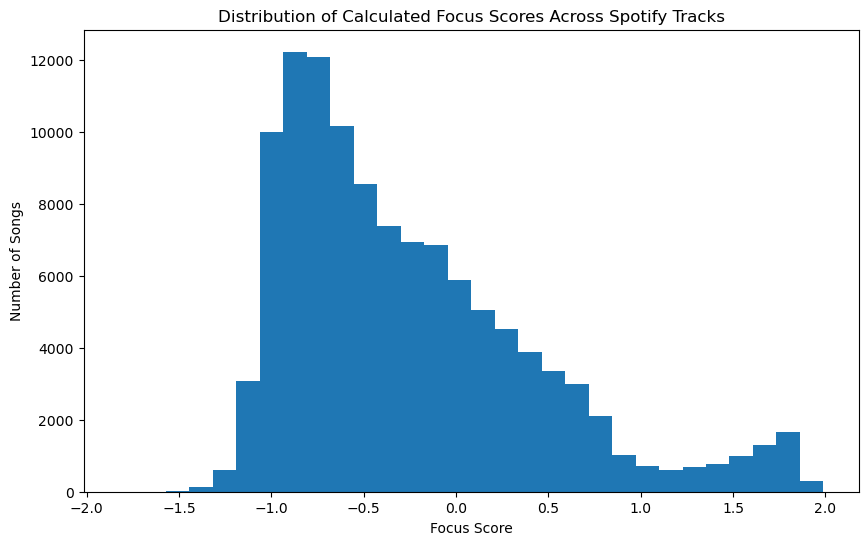

In [13]:
#visualizing focus score
#histogram to show how focus_score is distributed across all songs
plt.figure(figsize=(10, 6))

#plot the distribution of focus_score
plt.hist(df["focus_score"], bins=30)

#title and axis labels
plt.title("Distribution of Calculated Focus Scores Across Spotify Tracks")

plt.xlabel("Focus Score")
plt.ylabel("Number of Songs")

#display plot
plt.show()

In [14]:
#randomly sample 5000 songs so scatter plots are less dense and easier to read
#random_state makes the sample reproducible, so the same rows are chosen each time
sample_df = df.sample(5000, random_state=42)

## Feature Relationships and Focus Score Behavior

The following scatter plots are used to examine:
- natural relationships in the data, such as acousticness versus energy
- how the focus score behaves relative to selected features

Because acousticness and energy are included directly in the focus score formula, their relationships with the focus score are partly constructed by design. These plots are therefore used to validate the behavior of the experimental formula, while plots involving features not directly included in the formula, such as tempo, provide more independent insight into the validity of the formula.

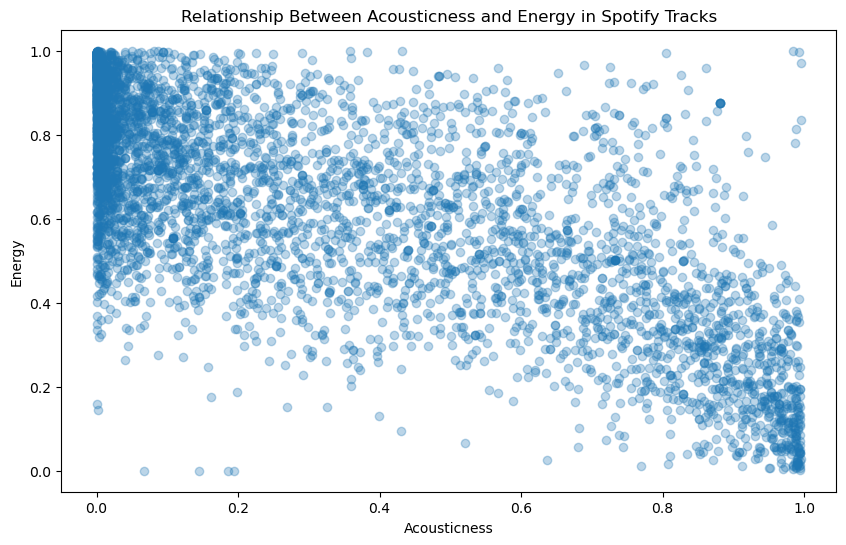

In [15]:
plt.figure(figsize=(10,6))

#scatter plot comparing acousticness and energy
plt.scatter(
    sample_df["acousticness"],  #values for x-axis
    sample_df["energy"],        #values for y-axis
    alpha=0.3                   #transparent points so data is easier to read
)

#title and axis labels
plt.title("Relationship Between Acousticness and Energy in Spotify Tracks")

plt.xlabel("Acousticness")
plt.ylabel("Energy")

#save chart to images folder
plt.savefig("images/acousticness_vs_energy.png", bbox_inches="tight")

#display plot
plt.show()

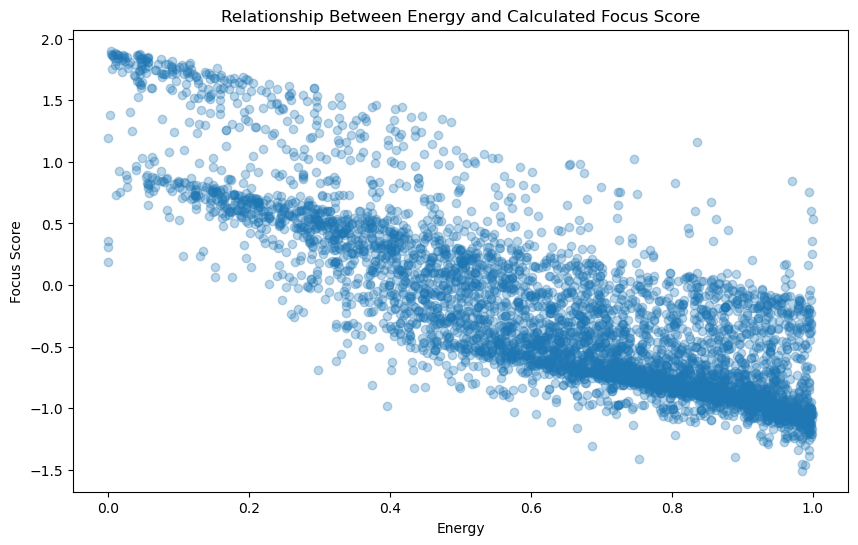

In [16]:
plt.figure(figsize=(10,6))

#scatter plot comparing focus_score and energy
plt.scatter(
    sample_df["energy"],       #values for x-axis 
    sample_df["focus_score"],  #values for y-axis 
    alpha=0.3                  
)

#title and axis labels
plt.title("Relationship Between Energy and Calculated Focus Score")

plt.xlabel("Energy")
plt.ylabel("Focus Score")

#display plot
plt.show()

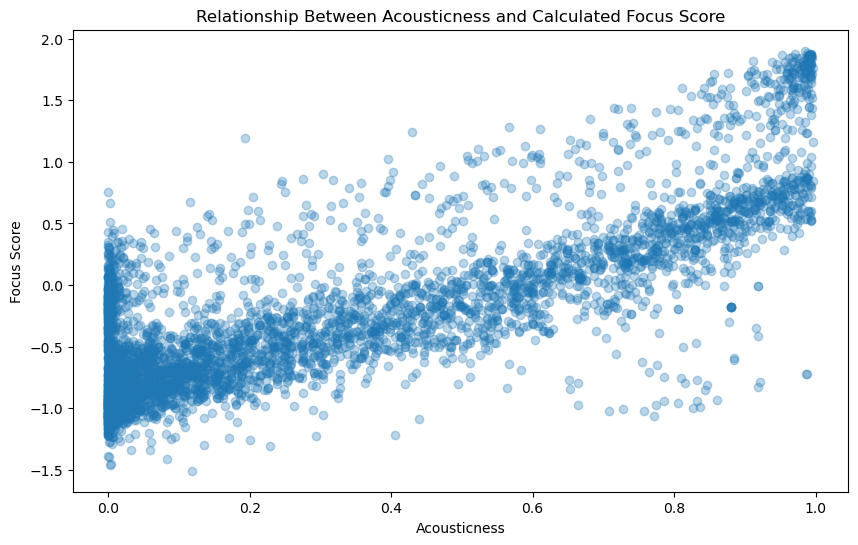

In [17]:
plt.figure(figsize=(10,6))

#scatter plot comparing acousticness and focus_score
plt.scatter(
    sample_df["acousticness"],   #x-axis values
    sample_df["focus_score"],    #y-axis values
    alpha=0.3                    
)

#title and axis labels
plt.title("Relationship Between Acousticness and Calculated Focus Score")

plt.xlabel("Acousticness")
plt.ylabel("Focus Score")

#display plot
plt.show()

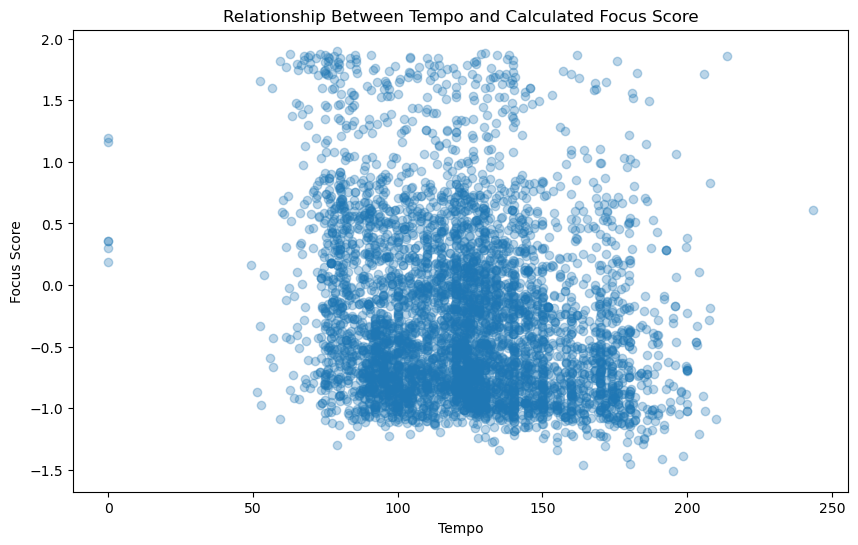

In [18]:
plt.figure(figsize=(10,6))

#scatter plot comparing tempo and focus_score
plt.scatter(
    sample_df["tempo"],        #x-axis values 
    sample_df["focus_score"],  #y-axis values 
    alpha=0.3                  
)

#title and axis labels
plt.title("Relationship Between Tempo and Calculated Focus Score")

plt.xlabel("Tempo")
plt.ylabel("Focus Score")

#display plot
plt.show()

In [19]:
#100 highest focus score songs
top_focus = df.sort_values(by="focus_score", ascending=False).head(100)

#100 lowest focus score songs
low_focus = df.sort_values(by="focus_score", ascending=True).head(100)

#calculate average features for high focus songs
print("Average features for HIGH focus score songs:")
print(top_focus[["acousticness","instrumentalness","energy","speechiness","tempo"]].mean())

print("\n---------------------------------\n")

#calculate average features for low focus songs
print("Average features for LOW focus score songs:")
print(low_focus[["acousticness","instrumentalness","energy","speechiness","tempo"]].mean())

Average features for HIGH focus score songs:
acousticness         0.987350
instrumentalness     0.968630
energy               0.010005
speechiness          0.036316
tempo               79.414180
dtype: float64

---------------------------------

Average features for LOW focus score songs:
acousticness          0.025171
instrumentalness      0.011081
energy                0.956460
speechiness           0.513210
tempo               143.552110
dtype: float64


## Comparing High-Scoring and Low-Scoring Tracks

To better understand the characteristics of tracks ranked highly by the focus score, we compare the 100 highest-scoring tracks to the 100 lowest-scoring tracks.

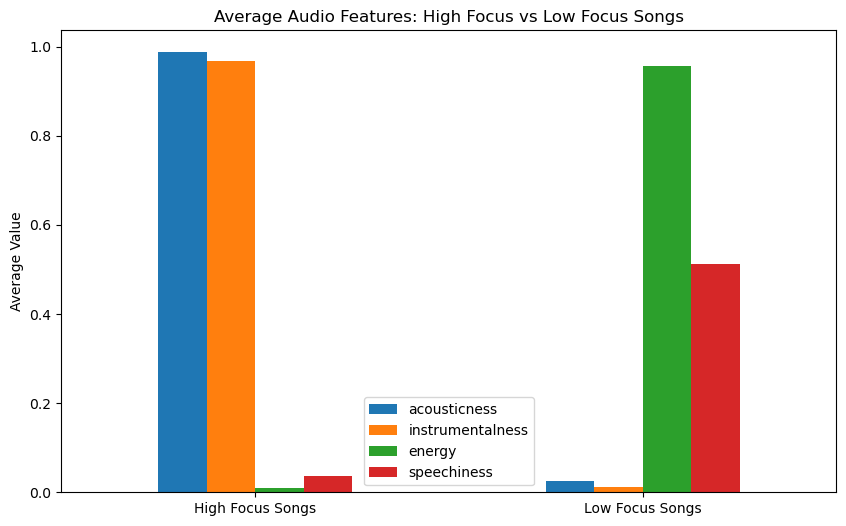

In [20]:
#calculate mean values for top and low focus songs
top_means = top_focus[["acousticness","instrumentalness","energy","speechiness"]].mean()
low_means = low_focus[["acousticness","instrumentalness","energy","speechiness"]].mean()

#combine them into a DataFrame for easy plotting
comparison = pd.DataFrame({
    "High Focus Songs": top_means,
    "Low Focus Songs": low_means
})

#features become x-axis labels
comparison = comparison.T

#plot bar chart
comparison.plot(kind="bar", figsize=(10,6))

#title and axis labels
plt.title("Average Audio Features: High Focus vs Low Focus Songs")

plt.ylabel("Average Value")
plt.xticks(rotation=0)

#save chart to images folder
plt.savefig("images/high_vs_low_focus_features.png", bbox_inches="tight")

#display plot
plt.show()

## Top Tracks Ranked by the Focus Score

Below are the top tracks ranked by the calculated focus score heuristic.

In [21]:
#select relevant columns for recommendations
focus_recommendations = df[[
    "track_name",
    "artists",
    "focus_score",
    "acousticness",
    "instrumentalness",
    "energy",
    "speechiness",
    "tempo"
]]

#sort songs by highest focus score
focus_recommendations = focus_recommendations.sort_values(
    by="focus_score",
    ascending=False
)

#display top 10 focus-friendly songs
focus_recommendations.head(10)

,track_name,artists,focus_score,acousticness,instrumentalness,energy,speechiness,tempo
101490,Hair Salon,Deep Sleep Hair Dryers;Hair Dryers for Backgro...,1.988980,0.990,0.999,0.000020,0.0000,0.000
101440,Hair Dryer Sound 20 - Loopable With No Fade,Deep Sleep Hair Dryers;Hair Dryer Collection;H...,1.978970,0.988,0.991,0.000030,0.0000,0.000
101632,Deeper Sounding Vacuum Cleaner 2 - Stationary,Deep Sleep Vacuum Cleaners;White Noise Vacuum ...,1.964941,0.996,0.969,0.000059,0.0000,0.000
101381,Deeper Sounding Vacuum Cleaner 2 - Stationary,Vacuum Cleaner White Noise;White Noise For Bab...,1.964941,0.996,0.969,0.000059,0.0000,0.000
101597,Weißes Rauschen: Aufwachen Total Entspannt,Weißes Rauschen HD,1.964920,0.977,0.988,0.000080,0.0000,0.000
101830,Pink Noise - BP 100 hz,Granular,1.963420,0.980,0.985,0.001580,0.0000,0.000
101919,Hair Dryer,Baby Sweet Dream,1.947700,0.981,1.000,0.033300,0.0000,0.000
101867,Hair Dryer (Baby White Noise Series),Baby Sweet Dream,1.947700,0.981,1.000,0.033300,0.0000,0.000
101286,Fan - Loopable with No Fade,White Noise Meditation,1.945980,0.956,0.990,0.000020,0.0000,0.000
101943,Baby Music For Babies,Baby Sleep Music;Baby Lullaby;Monarch Baby Lul...,1.942570,0.994,0.987,0.002530,0.0359,74.039


## Turning the Focus Score into Labels for Machine Learning

In [22]:
#create a binary label (top 25% only)

#calculate the 75th percentile (only the top 25% of songs will be labeled as focus-friendly)
focus_threshold = df["focus_score"].quantile(0.75)  

# assign 1 if the song is in the top 25% of focus scores, otherwise 0
df["is_focus_friendly"] = (df["focus_score"] > focus_threshold).astype(int)  

#print threshold for reference
print("Focus score threshold (75th percentile):", focus_threshold)

#check distribution of labels to make sure
print(df["is_focus_friendly"].value_counts())

#preview results
df[["track_name", "artists", "focus_score", "is_focus_friendly"]].head()

Focus score threshold (75th percentile): 0.11833575
is_focus_friendly
0    85500
1    28500
Name: count, dtype: int64


,track_name,artists,focus_score,is_focus_friendly
0,Comedy,Gen Hoshino,-0.571799,0
1,Ghost - Acoustic,Ben Woodward,0.681706,1
2,To Begin Again,Ingrid Michaelson;ZAYN,-0.204700,0
3,Can't Help Falling In Love,Kina Grannis,0.809171,1
4,Hold On,Chord Overstreet,-0.026600,0


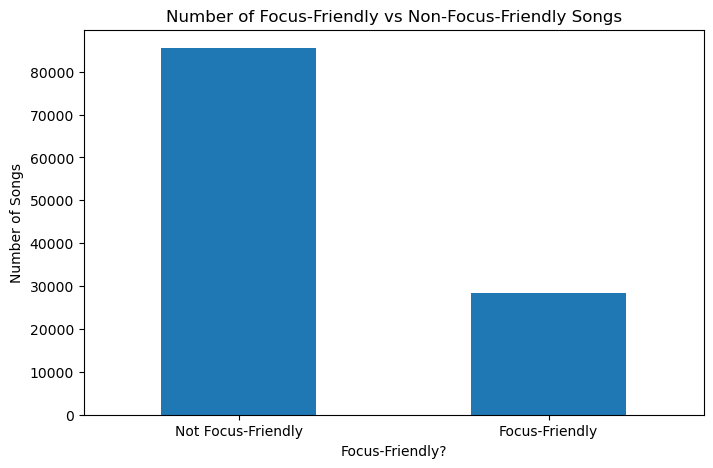

In [23]:
#visualize how many songs were labeled as focus-friendly vs not focus-friendly
plt.figure(figsize=(8, 5))  #create a figure

df["is_focus_friendly"].value_counts().sort_index().plot(kind="bar")  #count each label and plot it as a bar chart

#title and axis labels
plt.title("Number of Focus-Friendly vs Non-Focus-Friendly Songs")  

plt.xlabel("Focus-Friendly?")  
plt.ylabel("Number of Songs")  

#customize x-axis tick labels for readability
plt.xticks([0, 1], ["Not Focus-Friendly", "Focus-Friendly"], rotation=0)  # replace 0 and 1 with meaningful text labels

#display plot
plt.show()  

## Machine Learning Experiments for Predicting Focus-Friendly Songs

In this section, I compare two Logistic Regression models trained to predict whether a song is focus-friendly. The first model serves as a baseline using all heuristic-related features, while the second uses a reduced feature set to create a more realistic and interpretable classification task.

In [24]:
#import machine learning tools from scikit-learn

from sklearn.model_selection import train_test_split  #used to split the dataset into training data and testing data
from sklearn.linear_model import LogisticRegression  #the classification model we will train first
from sklearn.metrics import accuracy_score  #used to measure the overall percent of correct predictions
from sklearn.metrics import classification_report  #gives precision, recall, and f1-score for each class
from sklearn.metrics import confusion_matrix  #shows how many predictions were correct vs incorrect by class

In [25]:
#create y, which contains the target labels we want to predict, same variable is used for baseline and reduced model
y = df["is_focus_friendly"] #y is the target column where 1 means focus-friendly and 0 means not focus-friendly

## Baseline Model: Logistic Regression Using All Heuristic Features

This baseline model uses the full set of audio features, including the main variables used to construct the heuristic focus score. Because the target labels were derived from several of these same features, this model is expected to perform extremely well and serves mainly as a benchmark.

In [26]:
# define the full feature set for the baseline model

baseline_feature_columns = [
    #included in the original heuristic score   
    "acousticness",      
    "instrumentalness",  
    "energy",            
    "speechiness",       
   
    "danceability",      #add: captures rhythm/activity
    "valence",           #add: emotional tone
    "tempo",             #add: speed of song
    "loudness"           #add: intensity
]

#create the baseline feature matrix
X_baseline = df[baseline_feature_columns]  

#preview the first few rows
X_baseline.head()  

,acousticness,instrumentalness,energy,speechiness,danceability,valence,tempo,loudness
0,0.0322,0.000001,0.4610,0.1430,0.676,0.715,87.917,-6.746
1,0.9240,0.000006,0.1660,0.0763,0.420,0.267,77.489,-17.235
2,0.2100,0.000000,0.3590,0.0557,0.438,0.120,76.332,-9.734
3,0.9050,0.000071,0.0596,0.0363,0.266,0.143,181.740,-18.515
4,0.4690,0.000000,0.4430,0.0526,0.618,0.167,119.949,-9.681


In [27]:
#split the baseline dataset into training data and testing data

X_baseline_train, X_baseline_test, y_baseline_train, y_baseline_test = train_test_split(
    X_baseline,             #baseline input features
    y,                      #target labels
    test_size=0.2,          #use 20% of the data for testing and 80% for training
    random_state=42,        #set a fixed random seed so results are reproducible
    stratify=y              #labels are currently imbalanced (25% are 1), preserve the same class proportion in both the training set and test set
)

#print the shapes of the baseline datasets
print("X_baseline_train shape:", X_baseline_train.shape)  #show the number of training rows and columns
print("X_baseline_test shape:", X_baseline_test.shape)    #show the number of testing rows and columns
print("y_baseline_train shape:", y_baseline_train.shape)  #show the number of training labels
print("y_baseline_test shape:", y_baseline_test.shape)    #show the number of testing labels

X_baseline_train shape: (91200, 8)
X_baseline_test shape: (22800, 8)
y_baseline_train shape: (91200,)
y_baseline_test shape: (22800,)


In [28]:
#create and train the logistic regression model

baseline_model = LogisticRegression(
    class_weight="balanced",  #help the model pay more attention to the minority class (focus-friendly songs) and avoid overpredicting the majority class
    max_iter=1000,            #allow more iterations so the model has enough time to converge
    random_state=42           #keep results reproducible
)

#train the model using the training data
baseline_model.fit(X_baseline_train, y_baseline_train)  #learn the relationship between audio features and focus-friendly labels

#confirm that training is complete
print("Baseline logistic regression model trained successfully.")

Baseline logistic regression model trained successfully.


In [29]:
#use the baseline model to make predictions on the test data

y_baseline_pred = baseline_model.predict(X_baseline_test)  #predict whether each test song is focus-friendly or not

#preview the first few predictions
print("First 10 predictions:", y_baseline_pred[:10])  #show the first 10 predicted labels
print("First 10 actual values:", y_baseline_test.iloc[:10].values)  #show the first 10 true labels for comparison

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 0]


In [30]:
#calculate baseline model accuracy

baseline_accuracy = accuracy_score(y_baseline_test, y_baseline_pred) #compute the percentage of correct predictions on the test set

#display the baseline model's accuracy score
print("Baseline Accuracy:", baseline_accuracy)

# print a full classification report
print("\nBaseline Classification Report:\n") 
print(classification_report(y_baseline_test, y_baseline_pred))  #show precision, recall, and f1-score for both classes

#build a confusion matrix to compare actual vs predicted labels
baseline_cm = confusion_matrix(y_baseline_test, y_baseline_pred)

#display the confusion matrix as a table of counts
print("Baseline Confusion Matrix:\n", baseline_cm) 

Baseline Accuracy: 0.9899561403508772

Baseline Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     17100
           1       0.96      1.00      0.98      5700

    accuracy                           0.99     22800
   macro avg       0.98      0.99      0.99     22800
weighted avg       0.99      0.99      0.99     22800

Baseline Confusion Matrix:
 [[16871   229]
 [    0  5700]]


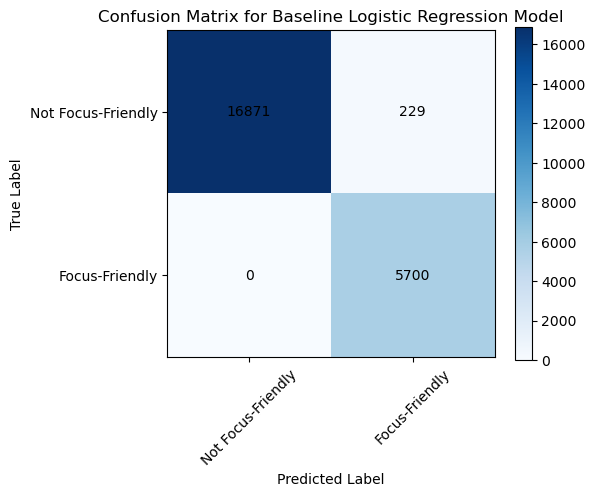

In [31]:
#visualize the confusion matrix for baseline model

plt.figure(figsize=(6, 5))  

#display the confusion matrix as a color-coded image
plt.imshow(baseline_cm, interpolation="nearest", cmap="Blues") 

#add a title a color scale to show the meaning of darker vs lighter cells
plt.title("Confusion Matrix for Baseline Logistic Regression Model")  
plt.colorbar()  

#label the axes with class names
tick_marks = [0, 1]  # define tick positions for the two classes
plt.xticks(tick_marks, ["Not Focus-Friendly", "Focus-Friendly"], rotation=45)  
plt.yticks(tick_marks, ["Not Focus-Friendly", "Focus-Friendly"])  

#label the axes
plt.xlabel("Predicted Label")  
plt.ylabel("True Label")  

#display the count values inside each box
for i in range(baseline_cm.shape[0]):  #loop through each row 
    for j in range(baseline_cm.shape[1]):  #loop through each column 
        plt.text(j, i, baseline_cm[i, j], ha="center", va="center", color="black")  #place the count inside the cell

plt.tight_layout()  #reduce overlap and improve spacing

#display the confusion matrix plot
plt.show()  

In [32]:
#examine which features are most important in the baseline model

baseline_feature_importance = pd.DataFrame({
    "feature": baseline_feature_columns,          
    "coefficient": baseline_model.coef_[0]  #coefficients learned by the baseline model 
})

#sort features by importance (absolute value of coefficients)
baseline_feature_importance["abs_coefficient"] = baseline_feature_importance["coefficient"].abs()  #get magnitude of each coefficient

#sort from most important to least important
baseline_feature_importance = baseline_feature_importance.sort_values(by="abs_coefficient", ascending=False)

#display results
baseline_feature_importance

,feature,coefficient,abs_coefficient
0,acousticness,25.512289,25.512289
2,energy,-25.449724,25.449724
1,instrumentalness,25.032698,25.032698
3,speechiness,-21.028455,21.028455
5,valence,-0.482951,0.482951
4,danceability,0.060661,0.060661
7,loudness,-0.032071,0.032071
6,tempo,-0.000087,0.000087


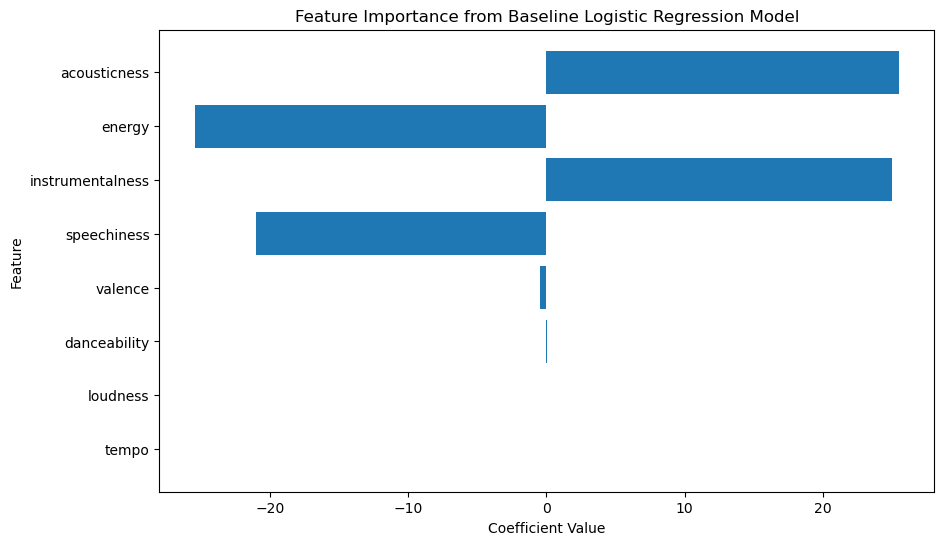

In [33]:
#visualize feature importance for baseline model

plt.figure(figsize=(10, 6))  

#horizontal bar chart of feature importance
plt.barh(baseline_feature_importance["feature"], baseline_feature_importance["coefficient"]) 

#title and axis labels
plt.title("Feature Importance from Baseline Logistic Regression Model")
plt.xlabel("Coefficient Value")  
plt.ylabel("Feature")  

#most important feature appears at the top
plt.gca().invert_yaxis()  

#display plot
plt.show()  

### Baseline Model Interpretation

The baseline model achieved extremely high performance because the target labels were derived from several of the same input features used during training. This means the model was able to reconstruct the logic of the original heuristic scoring function very closely. While this result is useful as a benchmark, it is not the most realistic representation of how the model would perform on more independent labeling criteria.

## Revised Model: Logistic Regression Using a Reduced Feature Set

To make the classification task more realistic, I retrained the model using a reduced feature set. I removed `energy` and `speechiness`, which were two of the most directly influential variables in the original heuristic formula, so the model would have to rely on more generalized patterns instead of closely reconstructing the label definition.

### Defining the Reduced Feature Set

In [34]:
#choose the reduced input features for the revised model, excluding energy and speechiness from the original heuristic score

feature_columns = [
    "acousticness",      #keep: strong signal for calm music
    "instrumentalness",  #keep: strong signal for focus (no lyrics)
    
    "danceability",      
    "valence",           
    "tempo",             
    "loudness"           
]

#create X, which contains the input features
X = df[feature_columns] #X is the feature matrix the model will learn from

#display the first few rows of X so we can verify the selected features, preview the feature data the model will use
X.head()  

,acousticness,instrumentalness,danceability,valence,tempo,loudness
0,0.0322,0.000001,0.676,0.715,87.917,-6.746
1,0.9240,0.000006,0.420,0.267,77.489,-17.235
2,0.2100,0.000000,0.438,0.120,76.332,-9.734
3,0.9050,0.000071,0.266,0.143,181.740,-18.515
4,0.4690,0.000000,0.618,0.167,119.949,-9.681


In [35]:
#split the dataset into training data and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,                      #input features
    y,                      #target labels
    test_size=0.2,          #use 20% of the data for testing and 80% for training
    random_state=42,        #set a fixed random seed so results are reproducible
    stratify=y              #labels are currently imbalanced (25% are 1), preserve the same class proportion in both the training set and test set
)

#print the shapes of the resulting datasets
print("X_train shape:", X_train.shape)  #show the number of training rows and columns
print("X_test shape:", X_test.shape)    #show the number of testing rows and columns
print("y_train shape:", y_train.shape)  #show the number of training labels
print("y_test shape:", y_test.shape)    #show the number of testing labels

X_train shape: (91200, 6)
X_test shape: (22800, 6)
y_train shape: (91200,)
y_test shape: (22800,)


### Training the Revised Logistic Regression Model

In [36]:
#create and train the logistic regression model

log_model = LogisticRegression(
    class_weight="balanced",  #help the model pay more attention to the minority class (focus-friendly songs) and avoid overpredicting the majority class
    max_iter=1000,            #allow more iterations so the model has enough time to converge
    random_state=42           #keep results reproducible
)

#train the model using the training data
log_model.fit(X_train, y_train)  #learn the relationship between audio features and focus-friendly labels

#confirm that training is complete
print("Logistic Regression model trained successfully.")  

Logistic Regression model trained successfully.


In [37]:
#use the trained model to make predictions on the test data

y_pred = log_model.predict(X_test)  #predict whether each test song is focus-friendly or not

#preview the first few predictions
print("First 10 predictions:", y_pred[:10])  #show the first 10 predicted labels
print("First 10 actual values:", y_test.iloc[:10].values)  #show the first 10 true labels for comparison

First 10 predictions: [0 0 0 1 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 0 0 0 0 0 0]


### Evaluating Revised Model Performance

In [38]:
#calculate the model's overall accuracy

accuracy = accuracy_score(y_test, y_pred)  #compute the percentage of correct predictions on the test set

#display the model's accuracy score
print("Accuracy:", accuracy)  

# print a full classification report
print("\nClassification Report:\n")  
print(classification_report(y_test, y_pred))  #show precision, recall, and f1-score for both classes

#build a confusion matrix to compare actual vs predicted labels
cm = confusion_matrix(y_test, y_pred)  

#display the confusion matrix as a table of counts
print("Confusion Matrix:\n", cm)  

Accuracy: 0.9392105263157895

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.93      0.96     17100
           1       0.83      0.95      0.89      5700

    accuracy                           0.94     22800
   macro avg       0.91      0.94      0.92     22800
weighted avg       0.95      0.94      0.94     22800

Confusion Matrix:
 [[15975  1125]
 [  261  5439]]


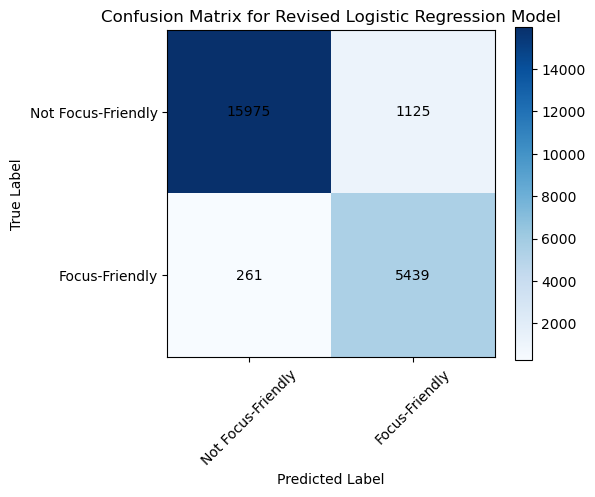

In [39]:
#visualize the confusion matrix with matplotlib

plt.figure(figsize=(6, 5))  

#display the confusion matrix as a color-coded image
plt.imshow(cm, interpolation="nearest", cmap="Blues")  

#add a title a color scale to show the meaning of darker vs lighter cells
plt.title("Confusion Matrix for Revised Logistic Regression Model") 
plt.colorbar()  

#label the axes with class names
tick_marks = [0, 1]  # define tick positions for the two classes
plt.xticks(tick_marks, ["Not Focus-Friendly", "Focus-Friendly"], rotation=45)  
plt.yticks(tick_marks, ["Not Focus-Friendly", "Focus-Friendly"])  

#label the axes
plt.xlabel("Predicted Label")  
plt.ylabel("True Label")  

#display the count values inside each box
for i in range(cm.shape[0]):  #loop through each row 
    for j in range(cm.shape[1]):  #loop through each column 
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")  #place the count inside the cell

plt.tight_layout()  # reduce overlap and improve spacing

#display the confusion matrix plot
plt.show()  

In [40]:
#examine which features are most important in the revised logistic regression model

feature_importance = pd.DataFrame({
    "feature": feature_columns,  
    "coefficient": log_model.coef_[0]  #coefficients learned by the model for each feature
})

#sort features by importance (absolute value of coefficients)
feature_importance["abs_coefficient"] = feature_importance["coefficient"].abs()  #get magnitude of each coefficient

#sort from most important to least important
feature_importance = feature_importance.sort_values(by="abs_coefficient", ascending=False)  

#display results
feature_importance

,feature,coefficient,abs_coefficient
0,acousticness,13.817458,13.817458
1,instrumentalness,9.276190,9.276190
3,valence,-2.379943,2.379943
2,danceability,0.692440,0.692440
5,loudness,-0.362467,0.362467
4,tempo,-0.002888,0.002888


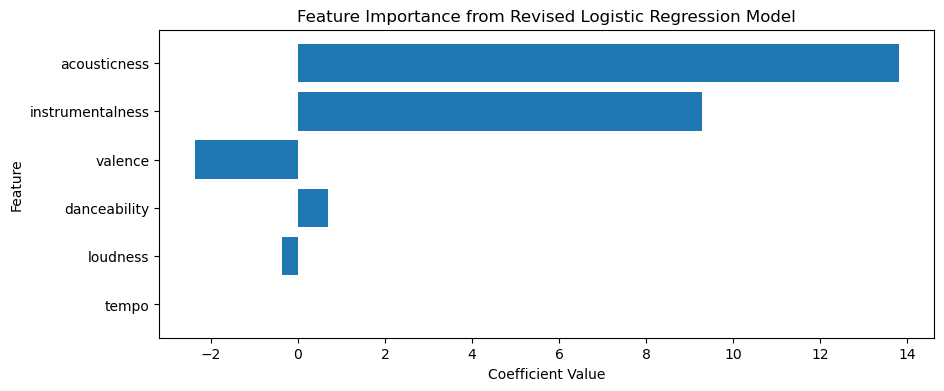

In [41]:
#visualize feature importance for the revised model

plt.figure(figsize=(10, 4))  

#horizontal bar chart of feature importance
plt.barh(feature_importance["feature"], feature_importance["coefficient"])  

#title and axis labels
plt.title("Feature Importance from Revised Logistic Regression Model")
plt.xlabel("Coefficient Value")  
plt.ylabel("Feature")  

#most important feature appears at the top
plt.gca().invert_yaxis()  

#display plot
plt.show()  

### Revised Model Interpretation

The revised model produced lower accuracy than the baseline model, but it provides a more realistic evaluation of predictive performance. By removing `energy` and `speechiness`, the model could no longer rely as directly on the same variables used to construct the labels.

Even after this reduction, `acousticness` and `instrumentalness` remained the strongest positive predictors of focus-friendly songs. This suggests that calm, instrumental tracks are consistently associated with higher focus potential, even when the model is forced to rely on a less direct feature set.

## Comparing the Two Models

The baseline model achieved higher accuracy because it included features that were directly used to construct the target labels. This made the classification task easier, but also made the model less representative of a real-world prediction setting.

The revised model used a reduced feature set by removing `energy` and `speechiness`, two variables that were strongly embedded in the original heuristic formula. Although this lowered performance, it created a more realistic and more interpretable modeling task.

Comparing the two models shows how feature selection can significantly affect model accuracy, interpretability, and realism. It also highlights the importance of thinking carefully about how labels are constructed in supervised machine learning.

In [42]:
#create a summary table comparing the two models

model_summary = pd.DataFrame({
    "Model": ["Baseline Model", "Revised Model"],
    "Accuracy": [baseline_accuracy, accuracy],
    "Features Used": [len(baseline_feature_columns), len(feature_columns)],
    "Class 1 Precision": [
        classification_report(y_baseline_test, y_baseline_pred, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    ],
    "Class 1 Recall": [
        classification_report(y_baseline_test, y_baseline_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]
    ],
    "Class 1 F1-Score": [
        classification_report(y_baseline_test, y_baseline_pred, output_dict=True)["1"]["f1-score"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"]
    ]
})

model_summary.round(3)

,Model,Accuracy,Features Used,Class 1 Precision,Class 1 Recall,Class 1 F1-Score
0,Baseline Model,0.990,8,0.961,1.000,0.980
1,Revised Model,0.939,6,0.829,0.954,0.887


In [43]:
#import joblib to save the trained machine learning model to a file
import joblib 

#save the revised logistic regression model
joblib.dump(log_model, "spotify_focus_model.pkl")  

print("Model saved successfully as spotify_focus_model.pkl")  

Model saved successfully as spotify_focus_model.pkl


## Limitations

This project uses a simplified experimental definition of focus-friendly music based on selected Spotify audio features. It does not account for listener preference, lyrical meaning, personal study habits, cultural context, or whether a track functions more like music, ambient sound, or white noise.

The machine learning portion also has an important limitation: the target labels were derived from the heuristic focus score rather than from independently collected user-labeled data. Because of this, the baseline model was able to closely reconstruct the scoring logic, which inflated its performance.

Even the revised model, while more realistic, is still limited by the fact that it predicts labels generated from the same dataset rather than a truly external definition of focus-friendly listening. The purpose of this project is therefore to explore how audio features can be combined for heuristic scoring and classification, not to create a definitive recommendation system.

## Conclusion

This project explored how Spotify audio features relate to music that may support focus or studying.

By analyzing relationships between acousticness, instrumentalness, energy, speechiness, and tempo, I created a heuristic focus score to estimate how suitable tracks may be for concentration-oriented listening.

I then extended the project with machine learning by training two Logistic Regression models to predict whether a song was focus-friendly. The baseline model achieved very high performance because it included features closely tied to the label construction process, while the revised model used a reduced feature set to produce a more realistic and interpretable result.

Across both the heuristic and machine learning analyses, acousticness and instrumentalness consistently emerged as the strongest positive indicators of focus-friendly music. Overall, this project demonstrates how audio feature data can be used for exploratory analysis, heuristic scoring, and supervised classification in a music-focused data science workflow.